In [1]:
from engine_api.math_service.math_model.tsp_runner import KCycleTSPRunner
from engine_api.math_service.math_model.tsp_config import *

In [2]:
runner = KCycleTSPRunner()

runner.load_data(
    DATA_SOURCE=DATA_SOURCE,
    EXCEL_PATH=EXCEL_PATH,
    TSPLIB_PATH=TSPLIB_PATH,
    s_value=s_value,
    k_value=k_value
)

runner.build_model(
    CONNECTIVITY=CONNECTIVITY,
    group_size=group_size,
    speed_kmph=speed_kmph,
    route_pace=route_pace,
    fuel_consumption=fuel_cons,
    fuel_price=fuel_price,
    use_osrm=True
)

🌐 Connecting to OSRM (Public API)...
🌍 OSRM Request (10 pts): http://router.project-osrm.org/table/v1/driving/22...
✅ OSRM data received.
✅ Using OSRM real-world data.



Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 106.206; 363 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 106.21
Total distance = 106.206 km
Total budget   = 10324.13 UAH
  - Locations: 9740.00 UAH
  - Fuel:      584.13 UAH
Total time     = 577.1 minutes
Tour: [1, 4, 7, 8, 3, 5, 1]


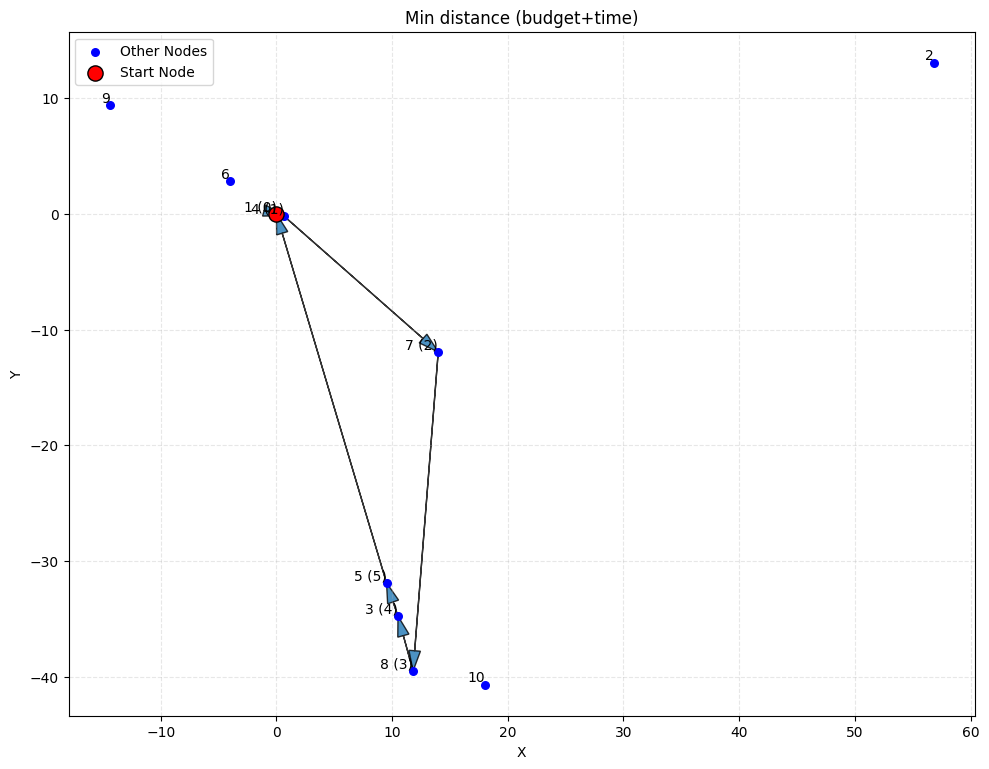

In [9]:
runner.apply_min_distance(budget_max=budget_max, time_max=time_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min distance (budget+time)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")


Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 7816.3295; 120 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 7816.33
Total distance = 122.969 km
Total budget   = 7816.33 UAH
  - Locations: 7140.00 UAH
  - Fuel:      676.33 UAH
Total time     = 598.3 minutes
Tour: [1, 4, 7, 8, 10, 3, 1]


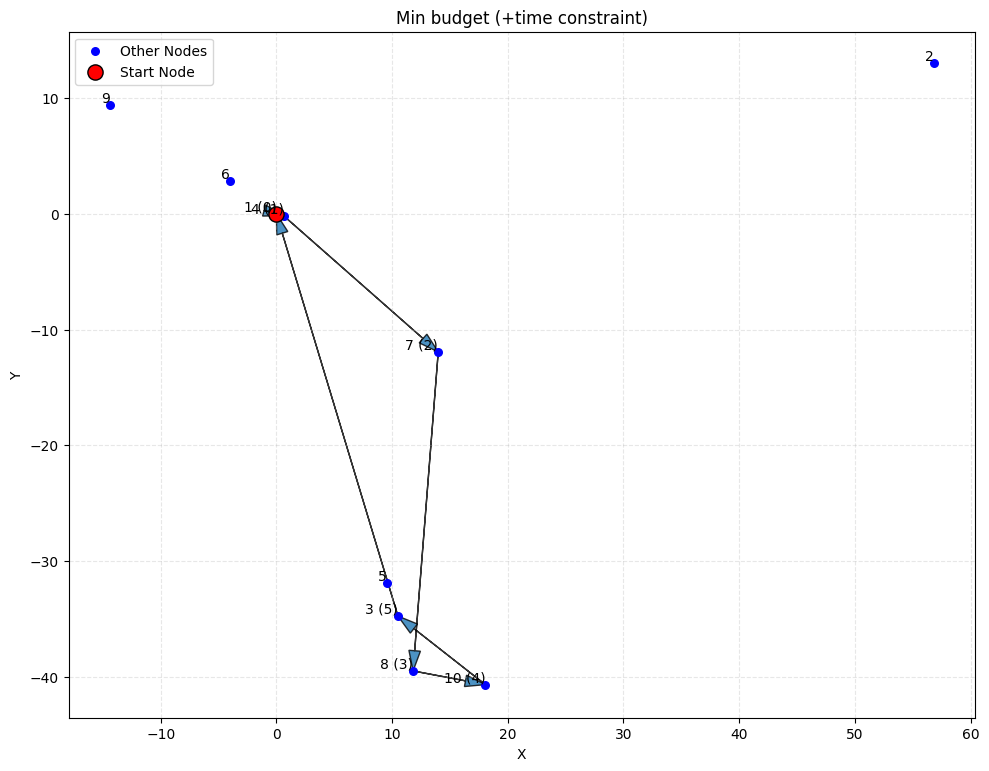

In [6]:
runner.apply_min_budget(time_max=time_max, dist_max=dist_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min budget (+time constraint)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")

'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().

Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 199
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 574.93; 192 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0

Objective = 574.93
Total distance = 108.537 km
Total budget   = 13036.95 UAH
  - Locations: 12440.00 UAH
  - Fuel:      596.95 UAH
Total time     = 574.9 minutes
Tour: [1, 6, 7, 3, 5, 4, 1]


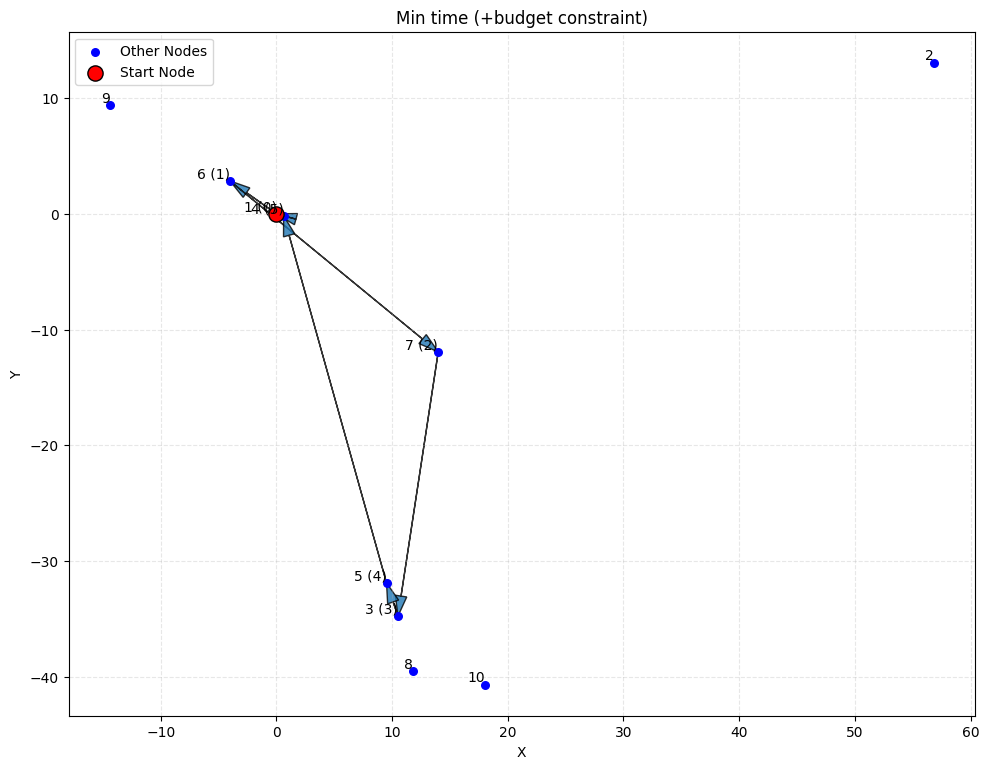

In [8]:
runner.apply_min_time(budget_max=budget_max, dist_max=dist_max)

results, ok = runner.solve(SOLVER=SOLVER, NEOS_EMAIL=NEOS_EMAIL, tee=False)

if ok:
    runner.print_metrics()
    runner.extract_tour()
    print("Tour:", runner.tour)
    runner.plot(title="Min time (+budget constraint)")
else:
    print("Cannot construct tour with provided constraints")
    print(f"Check your limits:\n - Budget: {budget_max} UAH\n - Time: {time_max:.1f} Hours\n - Number of places: {k_value}")
    print("Try increasing your budget/time or reducing the number of points.")